<a href="https://colab.research.google.com/github/Prashant230531/AI_FinalYear/blob/worksheet/Worksheet3_Prashant_Sharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementation of MCP Neuron for AND and OR Logic Gates
**Name:** Prashant Sharma

In [1]:
def MCP_Neurons_AND(X1, X2, T):
  """
  Simulates the AND logic gate using an MCP Neuron model for two binary input arrays.

  Parameters:
  -----------
  X1 (list): First input array containing binary values (0 or 1).
  X2 (list): Second input array containing binary values (0 or 1).
  T  (int) : Threshold value used to fire the neuron.

  Returns:
  --------
  state_neuron (list): Output list where each entry is 1 if neuron fires, else 0.
  """
  # Both input arrays must have equal length
  assert len(X1) == len(X2), "Input arrays must be of the same length"

  # Step 1: Add corresponding elements from X1 and X2
  total_input = [a + b for a, b in zip(X1, X2)]

  # Step 2: Apply threshold — neuron fires (1) if input meets or exceeds T
  state_neuron = [1 if val >= T else 0 for val in total_input]

  return state_neuron

In [2]:
# Testing MCP_Neurons_AND with standard AND gate inputs
# For AND gate, both inputs must be 1 to produce output 1
X1 = [0, 0, 1, 1]  # All possible combinations of first input
X2 = [0, 1, 0, 1]  # All possible combinations of second input
T = 2  # AND gate fires only when both inputs are 1 (sum = 2)

and_output = MCP_Neurons_AND(X1, X2, T)
print(f"AND Gate Output for X1={X1}, X2={X2}, Threshold={T}: {and_output}")


AND Gate Output for X1=[0, 0, 1, 1], X2=[0, 1, 0, 1], Threshold=2: [0, 0, 0, 1]


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Simulates the OR logic gate using an MCP Neuron model for two binary input arrays.

    Parameters:
    -----------
    X1 (list): First input array containing binary values (0 or 1).
    X2 (list): Second input array containing binary values (0 or 1).
    T  (int) : Threshold value used to fire the neuron.

    Returns:
    --------
    state_neuron (list): Output list where each entry is 1 if neuron fires, else 0.
    """
    # Validate that input arrays have the same length
    assert len(X1) == len(X2), "Input arrays must be of the same length"

    # Step 1: Compute element-wise sum of both input arrays
    total_input = [a + b for a, b in zip(X1, X2)]

    # Step 2: Neuron fires if the summed input is >= threshold T
    state_neuron = [1 if val >= T else 0 for val in total_input]

    return state_neuron


In [4]:
# Testing MCP_Neurons_OR with standard OR gate inputs
# OR gate outputs 1 when at least one input is 1
X1 = [0, 0, 1, 1]  # All possible combinations of first input
X2 = [0, 1, 0, 1]  # All possible combinations of second input
T = 1  # OR gate fires when sum >= 1 (at least one input is 1)

or_output = MCP_Neurons_OR(X1, X2, T)
print(f"OR Gate Output for X1={X1}, X2={X2}, Threshold={T}: {or_output}")


OR Gate Output for X1=[0, 0, 1, 1], X2=[0, 1, 0, 1], Threshold=1: [0, 1, 1, 1]


# Binary Classification: Digit 0 vs Digit 1 using Perceptron

## Step 1: Load the Dataset

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST subset containing only digits 0 and 1
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI/mnist_0_and_1.csv")

# Separate pixel features from class labels
X = df_0_1.drop(columns=["label"]).values  # Each row = 784 pixel values (28x28 image)
y = df_0_1["label"].values                 # Ground truth labels: 0 or 1

# Display the dimensions of loaded data
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


### Viewing Sample Images from the Dataset

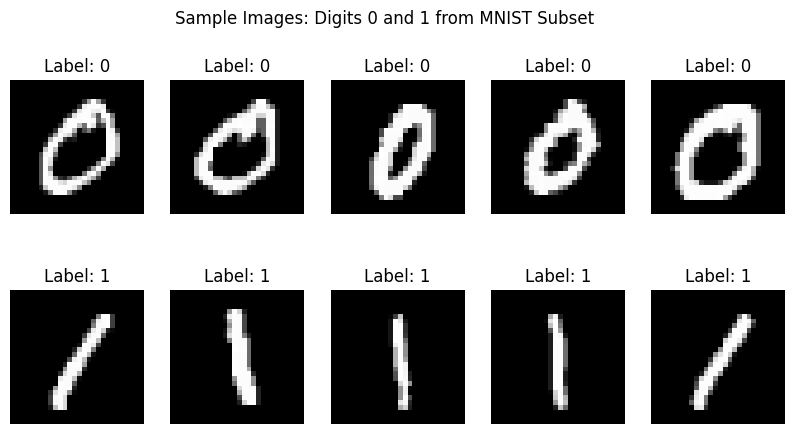

In [7]:
# Split data by class label for visualization
images_0 = X[y == 0]  # All images belonging to class 0
images_1 = X[y == 1]  # All images belonging to class 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Make sure there are at least 5 images per class before plotting
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Top row: samples from class 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Bottom row: samples from class 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("Sample Images: Digits 0 and 1 from MNIST Subset")
    plt.show()

## Step 2: Initialize Weights and Bias

In [8]:
# Initialize all weights to zero — one weight per pixel feature (784 total)
weights = np.zeros(X.shape[1])
bias = 0            # Bias term starts at zero
learning_rate = 0.1 # Controls how fast the model updates weights
epochs = 100        # Number of complete passes over the training data

## Step 3: Define the Decision Function

In [9]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Generates class predictions using the learned weights and bias.

    Parameters:
    -----------
    X       : numpy array of shape (n_samples, n_features) — input data
    weights : numpy array of shape (n_features,) — trained weight vector
    bias    : scalar — trained bias term

    Returns:
    --------
    y_pred_all : numpy array — predicted class labels (0 or 1) for each sample
    """
    # Compute the weighted sum of inputs plus the bias
    net_input = np.dot(X, weights) + bias

    # Apply a step activation function: output 1 if net_input >= 0, else 0
    y_pred_all = np.where(net_input >= 0, 1, 0)
    return y_pred_all

## Step 4: Implement the Perceptron Learning Algorithm

In [10]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Trains a perceptron model by iteratively updating weights and bias.

    Parameters:
    -----------
    X             : numpy array (n_samples, n_features) — training feature matrix
    y             : numpy array (n_samples,) — true class labels
    weights       : numpy array (n_features,) — initial weight vector
    bias          : scalar — initial bias
    learning_rate : float — step size for weight updates (default: 0.1)
    epochs        : int — number of full training iterations (default: 100)

    Returns:
    --------
    weights  : updated weight vector after training
    bias     : updated bias after training
    accuracy : classification accuracy on training data at the last epoch
    """
    n_samples = X.shape[0]
    accuracy = 0

    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(n_samples):
            # Compute net input for current sample
            net_input = np.dot(X[i], weights) + bias
            y_pred = 1 if net_input >= 0 else 0

            # If prediction is wrong, adjust weights and bias using the error
            if y_pred != y[i]:
                error = y[i] - y_pred
                weights += learning_rate * error * X[i]
                bias    += learning_rate * error
            else:
                correct_predictions += 1

        # Compute and display accuracy every 10 epochs
        epoch_accuracy = correct_predictions / n_samples
        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch + 1}: Accuracy = {epoch_accuracy:.4f}")

        accuracy = epoch_accuracy

    return weights, bias, accuracy

## Training the Perceptron Model

In [11]:
# Train the perceptron and retrieve updated parameters and final accuracy
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Training Accuracy:", accuracy)

Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
Final Training Accuracy: 1.0


## Step 5: Visualize Any Misclassified Images

In [12]:
# Use trained weights and bias to predict labels for the full dataset
net_output = np.dot(X, weights) + bias
y_pred = np.where(net_output >= 0, 1, 0)

# Report overall accuracy after training
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy on Full Dataset: {final_accuracy:.4f}")

# Identify indices where the model made wrong predictions
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    # Display up to 10 misclassified samples
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Samples")
    plt.show()
else:
    print("No misclassifications — all samples predicted correctly!")

Final Accuracy on Full Dataset: 1.0000
No misclassifications — all samples predicted correctly!


# Perceptron Algorithm for Digit 3 vs Digit 5 Classification

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST subset containing only digits 3 and 5
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI/mnist_3_and_5.csv")

# Separate features from labels
X = df_3_5.drop(columns=["label"]).values  # Pixel values (784 features)
y = df_3_5["label"].values                 # Class labels: 3 or 5

# Print dataset dimensions to confirm successful loading
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
